In [9]:
.libPaths("/home/minghui/miniforge3/lib/R/library")

rm(list = ls())
gc()

setwd("/mnt/data00/Minghui/project_NMF/06_Test_NMF_Program_0213/")

library(rvest)
library(tidyverse)
library(clusterProfiler)

cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

library(org.Hs.eg.db)


In [11]:
filtered_modules_list <-readRDS('../04_Test_NMF_Program_0120/01_filtered_modules_list.rds')
filtered_modules_list


$BE_modules1
 [1] "A4GNT"    "AQP5"     "ASCL2"    "BPIFB1"   "C16orf89" "CD74"    
 [7] "CDCA7"    "CLDN10"   "CLDN2"    "CLU"      "CXCL17"   "DMKN"    
[13] "ELAPOR1"  "EPHB3"    "FAM3D"    "FMOD"     "FUT9"     "FXYD5"   
[19] "HLA.DMA"  "HLA.DPA1" "HLA.DRA"  "HLA.DRB1" "HLA.DRB5" "IFI6"    
[25] "IFITM3"   "KCNE2"    "LCN2"     "LIPF"     "LTF"      "LY6E"    
[31] "LYZ"      "MIA"      "MUC5B"    "MUC6"     "PDIA2"    "PDZK1IP1"
[37] "PGC"      "PIGR"     "PSMB9"    "RPS20"    "SELENOM"  "SLC12A2" 
[43] "SOD3"     "SYNE2"    "TESC"     "ZG16B"   

$BE_modules3
[1] "ACAT2"  "AGR2"   "FDPS"   "HMGCR"  "IDI1"   "INSIG1" "MVD"    "OCIAD2"
[9] "SCD"   

$BE_modules4
 [1] "ADGRF1" "EPS8L1" "GUCA2B" "HLA.E"  "ISG15"  "LAMB3"  "NTHL1"  "PCDH1" 
 [9] "SAMD9"  "SDCBP2" "SMIM6"  "SQSTM1" "TRIM29" "TXNIP" 

$BE_modules5
 [1] "ADH1C"    "C15orf48" "CAPS"     "CLDN15"   "GSTA1"    "MT1E"    
 [7] "MT1F"     "MT1G"     "MT1H"     "MT1M"     "MT1X"     "MT2A"    
[13] "NKX6.2"   "NUPR1"    "SCGB2A1"  "TAGLN2"   "UGT2B15" 

$BE_modules6
 [1] "ADIRF"    "AKR1C3"   "ALDOB"    "ANPEP"    "ANXA10"   "ANXA13"  
 [7] "C11orf86" "CEACAM5"  "CEACAM6"  "CES2"     "CLDN23"   "COL17A1" 
[13] "CRIP1"    "DEFB1"    "DHRS11"   "FABP1"    "FABP2"    "FXYD3"   
[19] "HPGD"     "IL32"     "ISG20"    "KRT19"    "KRT20"    "KRT8"    
[25] "LGALS3"   "LMO4"     "MALL"     "PHGR1"    "PLAC8"    "PRAP1"   
[31] "RGS2"     "SI"       "SLC26A3"  "SMIM24"   "SULT1A1"  "SULT1A2" 
[37] "TM4SF20"  "TM4SF4"   "TSPAN1"   "TSPAN8"  

$BE_modules7
 [1] "AGR3"    "CLDN4"   "CLDN7"   "GPA33"   "KRT17"   "LGALS4"  "ONECUT2"
 [8] "PRSS3"   "REG4"    "S100A10" "SQLE"    "TMEM45B"

$BE_modules8
 [1] "AKR1B10" "AKR1C1"  "AKR1C2"  "ALDH3A1" "ATP2A3"  "CA2"     "CYSTM1" 
 [8] "FGFBP1"  "GKN1"    "GKN2"    "HMGCS1"  "ID1"     "IFI27"   "IL1R2"  
[15] "MSMO1"   "MUC5AC"  "MUCL3"   "PKIB"    "PSCA"    "RAB27A"  "S100P"  
[22] "SFTA2"   "SLC5A5"  "SPINK1"  "SPTSSB"  "SULT1C2" "TFF1"    "VSIG1"  

$BE_modules10
 [1] "ANKRD37"   "AREG"      "ARL14"     "ARL5B"     "ATF3"      "BTG2"     
 [7] "C3orf52"   "CD55"      "CSRNP1"    "CXCL3"     "CXCL8"     "DNAJA1"   
[13] "DNAJB1"    "DUSP1"     "EFNA1"     "EGR1"      "ERRFI1"    "ETS2"     
[19] "EZR"       "FOS"       "FOSB"      "FRMD4B"    "GADD45B"   "GDF15"    
[25] "HBEGF"     "HERPUD1"   "HSPA1A"    "HSPA1B"    "IER2"      "IER3"     
[31] "IER5"      "ITPKC"     "JUN"       "JUNB"      "KDM6B"     "KLF2"     
[37] "KLF4"      "KLF6"      "MAFF"      "NCOA7"     "NFKBIA"    "NR4A1"    
[43] "ODC1"      "PHLDA2"    "PLAUR"     "PMAIP1"    "PPP1R15A"  "RAB11FIP1"
[49] "RHOB"      "RND3"      "SERTAD1"   "SGK1"      "SLC20A1"   "SLC38A2"  
[55] "SOCS3"     "TCIM"      "TENT5A"    "TGIF1"     "TMEM63B"   "TNFRSF12A"
[61] "TRIB1"     "TSC22D1"   "VMP1"      "YPEL2"     "ZBTB43"    "ZFP36"    
[67] "ZFP36L2"  

$BE_modules11
  [1] "ANLN"      "ANP32E"    "ARHGAP11A" "ARL6IP1"   "ASF1B"     "ASPM"     
  [7] "ATAD2"     "ATAD5"     "AURKA"     "AURKB"     "BIRC5"     "BRCA1"    
 [13] "BRCA2"     "BUB1"      "CCNA2"     "CCNB1"     "CCNB2"     "CDC20"    
 [19] "CDC25B"    "CDCA3"     "CDCA8"     "CDK1"      "CDKN3"     "CDT1"     
 [25] "CENPA"     "CENPE"     "CENPF"     "CENPK"     "CENPM"     "CENPN"    
 [31] "CENPU"     "CENPW"     "CENPX"     "CEP55"     "CHAF1A"    "CHEK1"    
 [37] "CKAP2"     "CKS1B"     "CKS2"      "DDX39A"    "DEK"       "DEPDC1"   
 [43] "DHFR"      "DLGAP5"    "DNAJC9"    "DNMT1"     "DTYMK"     "DUT"      
 [49] "ECT2"      "FAM111B"   "FANCI"     "FEN1"      "GGCT"      "GGH"      
 [55] "GINS2"     "GMNN"      "GPSM2"     "GTSE1"     "H2AX"      "H2AZ1"    
 [61] "H4C3"      "HELLS"     "HMGA1"     "HMGB1"     "HMGB2"     "HMGB3"    
 [67] "HMGN2"     "HMMR"      "HSP90AA1"  "HSPE1"     "KIF11"     "KIF20B"   
 [73] "KIF23"     "KIF4A"     "KIFC1"     "KNL1"      "KNSTRN"    "KPNA2"    
 [79] "LBR"       "LIG1"      "LMNB1"     "LSM5"      "MAD2L1"    "MCM2"     
 [85] "MCM3"      "MCM4"      "MCM5"   

In [121]:
hsa <- read.delim('https://rest.kegg.jp/list/pathway/hsa', sep = "\t",
           col.names = c('ID', 'Name')) %>%
    mutate(Name = str_replace(Name, ' - Homo sapiens \\(human\\)', ''))

gene_info <- read.delim('https://rest.kegg.jp/list/hsa', sep = '\t') %>%
    dplyr::select(1, 4) %>%
    rename_with(~c('hsa', 'info')) %>%
    mutate(symbol = str_extract(info, "(^[\\w-]+)[;,]", group = 1))

pathway <- read.delim('https://rest.kegg.jp/link/pathway/hsa', sep = '\t',
                      col.names = c('hsa', 'ID')) %>%
    mutate(ID = str_remove(ID, 'path:')) %>%
    inner_join(hsa) %>%
    inner_join(gene_info) %>%
    dplyr::select(c('Name', 'symbol'))



Joining with `by = join_by(ID)`
Joining with `by = join_by(hsa)`


In [122]:
url <- 'https://www.kegg.jp/kegg/pathway.html'
html <- read_html(url)

# CSS 选择器和空数据框
hsa <- data.frame(class = character(),
                  subclass = character(),
                  ID = character(),
                  name = character(),
                  stringsAsFactors = FALSE)

# 解析 HTML，获取代谢通路信息
metabolism_section <- html %>% html_nodes(css = "#metabolism, #metabolism ~ b, #metabolism ~ h4")

hsa <- data.frame(
    class = character(),
    subclass = character(),
    ID = character(),
    name = character(),
    stringsAsFactors = FALSE
)

cate <- NA
subcate <- NA

for (node in metabolism_section) {
    tag <- html_name(node)
    if (tag == 'h4') {
        cate <- str_trim(str_split(html_text(node), ' ', 
                                   simplify = TRUE)[, 2])
    } else if (tag == 'b') {
        subcate <- str_trim(str_extract(html_text(node), '(?<=\\s).+'))
        entries <- html_elements(
            html_element(node, xpath = "following-sibling::div[1]"), "dt, a")
        for (entry in entries) {
            entry_text <- html_text(entry, trim = TRUE)
            if (str_detect(entry_text, "^\\d{5}")) {
                entry_text <- str_extract(entry_text, "^(\\d+)", group = 1)
                hsa <- rbind(hsa, data.frame(
                    class = cate,
                    subclass = subcate,
                    ID = paste0("hsa", entry_text),
                    name = NA, stringsAsFactors = FALSE))
            } else if (!is.na(entry_text) && nrow(hsa) > 0 
                       && is.na(hsa$name[nrow(hsa)])) {
                hsa$name[nrow(hsa)] <- entry_text
              }
        }
    } else {
        stop('Unexpected value of ', tag)
    }
}

saveRDS(hsa,'./06_hsa.rds')

saveRDS(pathway,'./06_KEGG_pathway.rds')

## glycosylation pathway

In [67]:
head(pathway)

# glyco_pw <- pathway[grepl(pattern = "glycan|glycosylation|O-glycan|N-glycan",x = pathway$Name),]

,Name,symbol
,<chr>,<chr>
1,Glycolysis / Gluconeogenesis,ADH1A
2,Glycolysis / Gluconeogenesis,ADH1B
3,Glycolysis / Gluconeogenesis,ADH1C
4,Glycolysis / Gluconeogenesis,ADH4
5,Glycolysis / Gluconeogenesis,ADH5
6,Glycolysis / Gluconeogenesis,ADH6


In [123]:
head(enricher(gene_df$SYMBOL, TERM2GENE = pathway)@result)

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
HIF-1 signaling pathway,HIF-1 signaling pathway,HIF-1 signaling pathway,2/5,110/8547,0.01818182,31.08000,7.681868,0.001600401,0.05441363,0.04548508,INSR/LTBR,2
Aldosterone-regulated sodium reabsorption,Aldosterone-regulated sodium reabsorption,Aldosterone-regulated sodium reabsorption,1/5,38/8547,0.02631579,44.98421,6.574095,0.022038341,0.14131192,0.11812452,INSR,1
Type II diabetes mellitus,Type II diabetes mellitus,Type II diabetes mellitus,1/5,47/8547,0.02127660,36.37021,5.882525,0.027200591,0.14131192,0.11812452,INSR,1
Intestinal immune network for IgA production,Intestinal immune network for IgA production,Intestinal immune network for IgA production,1/5,49/8547,0.02040816,34.88571,5.754969,0.028344791,0.14131192,0.11812452,LTBR,1
Ovarian steroidogenesis,Ovarian steroidogenesis,Ovarian steroidogenesis,1/5,52/8547,0.01923077,32.87308,5.577385,0.030059073,0.14131192,0.11812452,INSR,1
Regulation of lipolysis in adipocytes,Regulation of lipolysis in adipocytes,Regulation of lipolysis in adipocytes,1/5,59/8547,0.01694915,28.97288,5.216115,0.034049656,0.14131192,0.11812452,INSR,1


In [ ]:
# library(clusterProfiler)
# library(org.Hs.eg.db)
# library(dplyr)
# library(ggplot2)
# options(repr.plot.width =9, repr.plot.height=3)

# # 可选：保存图
# plot_list <- list()

# # 遍历模块列表
# for (name in names(filtered_modules_list)) {
  
#   cat("Processing:", name, "\n")
  
#   # 1. SYMBOL 转换为 ENTREZID
#   gene_df <- tryCatch({
#     bitr(filtered_modules_list[[name]],
#          fromType = "SYMBOL",
#          toType = "ENTREZID",
#          OrgDb = org.Hs.eg.db) %>%
#       mutate(ENTREZID = as.integer(ENTREZID))
#   }, error = function(e) {
#     cat("  bitr failed for", name, "\n")
#     return(NULL)
#   })
  
#   if (is.null(gene_df) || nrow(gene_df) == 0) {
#     cat(" No mapped genes, skip.\n")
#     next
#   }

#   # 2. glycosylation 富集分析
#   enrich_res <- tryCatch({
#     enricher(gene_df$SYMBOL, TERM2GENE = pathway)
#   }, error = function(e) {
#     cat(" Enrichment failed for", name, "\n")
#     return(NULL)
#   })
  
#   if (is.null(enrich_res) || nrow(enrich_res@result) == 0) {
#     cat("  No enrichment results, skip.\n")
#     next
#   }

#   # 3. 提取结果并画图
#   df <- enrich_res@result %>%
#   filter(grepl("glycan|glycosylation|O-glycan|N-glycan", Description, ignore.case = TRUE))

#   p <- ggplot(df, aes(Count, Description, fill = -log10(p.adjust))) +
#     geom_col() +
#     scale_fill_gradientn(colours = colorRampPalette(c('#ffdbdb', '#f29c98'))(50)) +
#     labs(title = paste("Glycosylation Enrichment:", name), y = NULL, x = "Count") +
#     theme_bw() +
#     theme(
#       strip.background = element_blank(),
#       strip.text = element_text(size = 12),
#       strip.placement = "outside",
#       panel.grid = element_blank(),
#       axis.text = element_text(size = 10),
#       axis.title = element_text(size = 16)
#     )
  
#   print(p)  # 显示图
#   plot_list[[name]] <- p  # 保存图对象（可选）

#   # 可选：保存为文件
#   # ggsave(filename = paste0("glyco_", name, ".pdf"), plot = p, width = 8, height = 6)
# }


In [ ]:
df_list <- list()

for (name in names(filtered_modules_list)) {
  
  cat("Processing:", name, "\n")
  
  gene_df <- tryCatch({
    bitr(filtered_modules_list[[name]],
         fromType = "SYMBOL",
         toType = "ENTREZID",
         OrgDb = org.Hs.eg.db) %>%
      mutate(ENTREZID = as.integer(ENTREZID))
  }, error = function(e) {
    cat("  bitr failed for", name, "\n")
    return(NULL)
  })
  
  if (is.null(gene_df) || nrow(gene_df) == 0) {
    cat(" No mapped genes, skip.\n")
    next
  }

  # 2. glycosylation enrichment
  enrich_res <- tryCatch({
    enricher(gene_df$SYMBOL, TERM2GENE = pathway)
  }, error = function(e) {
    cat(" Enrichment failed for", name, "\n")
    return(NULL)
  })
  
  if (is.null(enrich_res) || nrow(enrich_res@result) == 0) {
    cat("  No enrichment results, skip.\n")
    next
  }

  df <- enrich_res@result %>%
  filter(grepl("glycan|glycosylation|O-glycan|N-glycan", Description, ignore.case = TRUE))

    df_list[[name]] <- df
}

In [94]:
res <- do.call(rbind, df_list)

#### separate

In [124]:
library(tidyr)
library(dplyr)

# with_pathway <- rownames(res)[grepl("\\.", rownames(res))]

df <- data.frame(full_name = rownames(res))


df_split <- df %>%
  separate(full_name, into = c("module", "pathway"), sep = "\\.", extra = "merge")


print(df_split)


Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 13 rows [1, 2, 3,
4, 7, 8, 9, 10, 11, 12, 21, 22, 23].”


                       module                                pathway
1                 BE_modules1                                   <NA>
2                BE_modules10                                   <NA>
3                BE_modules15                                   <NA>
4                BE_modules17                                   <NA>
5                BE_modules19 Various types of N-glycan biosynthesis
6                BE_modules19                  N-Glycan biosynthesis
7  Healthy_intestine_modules1                                   <NA>
8  Healthy_intestine_modules3                                   <NA>
9  Healthy_intestine_modules5                                   <NA>
10   Healthy_stomach_modules1                                   <NA>
11   Healthy_stomach_modules3                                   <NA>
12   Healthy_stomach_modules4                                   <NA>
13   Healthy_stomach_modules6          Glycosaminoglycan degradation
14   Healthy_stomach_modules6 Vari

In [125]:
head(res)

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,module
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
BE_modules1,Mannose type O-glycan biosynthesis,Mannose type O-glycan biosynthesis,1/19,23/8545,0.043478261,19.553776,4.2059123,0.04997222,0.1737542,0.1324442,FUT9,1,BE_modules1
BE_modules10,Proteoglycans in cancer,Proteoglycans in cancer,3/42,204/8545,0.014705882,2.991947,2.0237317,0.07809346,0.1797389,0.1200434,EZR/HBEGF/PLAUR,3,BE_modules10
BE_modules15,Proteoglycans in cancer,Proteoglycans in cancer,2/66,204/8545,0.009803922,1.269311,0.3434709,0.47014329,0.8520622,0.8520622,CD44/MYC,2,BE_modules15
BE_modules17,Mucin type O-glycan biosynthesis,Mucin type O-glycan biosynthesis,1/14,36/8545,0.027777778,16.954365,3.8858513,0.05743610,0.1816061,0.1547520,ST6GALNAC1,1,BE_modules17
BE_modules19.Various types of N-glycan biosynthesis,Various types of N-glycan biosynthesis,Various types of N-glycan biosynthesis,1/7,43/8545,0.023255814,28.388704,5.1552144,0.03470994,0.1623702,0.1446212,MAN1A1,1,BE_modules19
BE_modules19.N-Glycan biosynthesis,N-Glycan biosynthesis,N-Glycan biosynthesis,1/7,55/8545,0.018181818,22.194805,4.5150077,0.04421008,0.1623702,0.1446212,MAN1A1,1,BE_modules19


In [126]:
res$module <- df_split$module

In [ ]:
library(dplyr)
library(tidyr)
library(pheatmap)

count_mat <- res %>%
  dplyr::select(module, Description, p.adjust) %>%
  pivot_wider(names_from = Description, values_from = p.adjust, values_fill = 0) %>%
  column_to_rownames("module") %>%
  as.matrix()

count_mat <- -log10(count_mat)

count_mat[which(count_mat == Inf) ]<- 0

geneid_mat <- res %>%
  dplyr::select(module, Description, geneID) %>%
  pivot_wider(names_from = Description, values_from = geneID, values_fill = "") %>%
  column_to_rownames("module") %>%
  as.matrix()

In [161]:
head(res)

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,module
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
BE_modules1,Mannose type O-glycan biosynthesis,Mannose type O-glycan biosynthesis,1/19,23/8545,0.043478261,19.553776,4.2059123,0.04997222,0.1737542,0.1324442,FUT9,1,BE_modules1
BE_modules10,Proteoglycans in cancer,Proteoglycans in cancer,3/42,204/8545,0.014705882,2.991947,2.0237317,0.07809346,0.1797389,0.1200434,EZR/HBEGF/PLAUR,3,BE_modules10
BE_modules15,Proteoglycans in cancer,Proteoglycans in cancer,2/66,204/8545,0.009803922,1.269311,0.3434709,0.47014329,0.8520622,0.8520622,CD44/MYC,2,BE_modules15
BE_modules17,Mucin type O-glycan biosynthesis,Mucin type O-glycan biosynthesis,1/14,36/8545,0.027777778,16.954365,3.8858513,0.05743610,0.1816061,0.1547520,ST6GALNAC1,1,BE_modules17
BE_modules19.Various types of N-glycan biosynthesis,Various types of N-glycan biosynthesis,Various types of N-glycan biosynthesis,1/7,43/8545,0.023255814,28.388704,5.1552144,0.03470994,0.1623702,0.1446212,MAN1A1,1,BE_modules19
BE_modules19.N-Glycan biosynthesis,N-Glycan biosynthesis,N-Glycan biosynthesis,1/7,55/8545,0.018181818,22.194805,4.5150077,0.04421008,0.1623702,0.1446212,MAN1A1,1,BE_modules19


In [171]:
saveRDS(res,'./06_gly_pathway.rds')

write_csv(res,file = './06_gly_pathway.csv',)

In [162]:
count_mat %>% head()

,Mannose type O-glycan biosynthesis,Proteoglycans in cancer,Mucin type O-glycan biosynthesis,Various types of N-glycan biosynthesis,N-Glycan biosynthesis,Glycosaminoglycan degradation,Other types of O-glycan biosynthesis
BE_modules1,0.7600647,0.00000000,0.0000000,0.0000000,0.0000000,0,0
BE_modules10,0.0000000,0.74535791,0.0000000,0.0000000,0.0000000,0,0
BE_modules15,0.0000000,0.06952872,0.0000000,0.0000000,0.0000000,0,0
BE_modules17,0.0000000,0.00000000,0.7408696,0.0000000,0.0000000,0,0
BE_modules19,0.0000000,0.00000000,0.0000000,0.7894937,0.7894937,0,0
Healthy_intestine_modules1,0.0000000,0.02719769,0.0000000,0.0000000,0.0000000,0,0


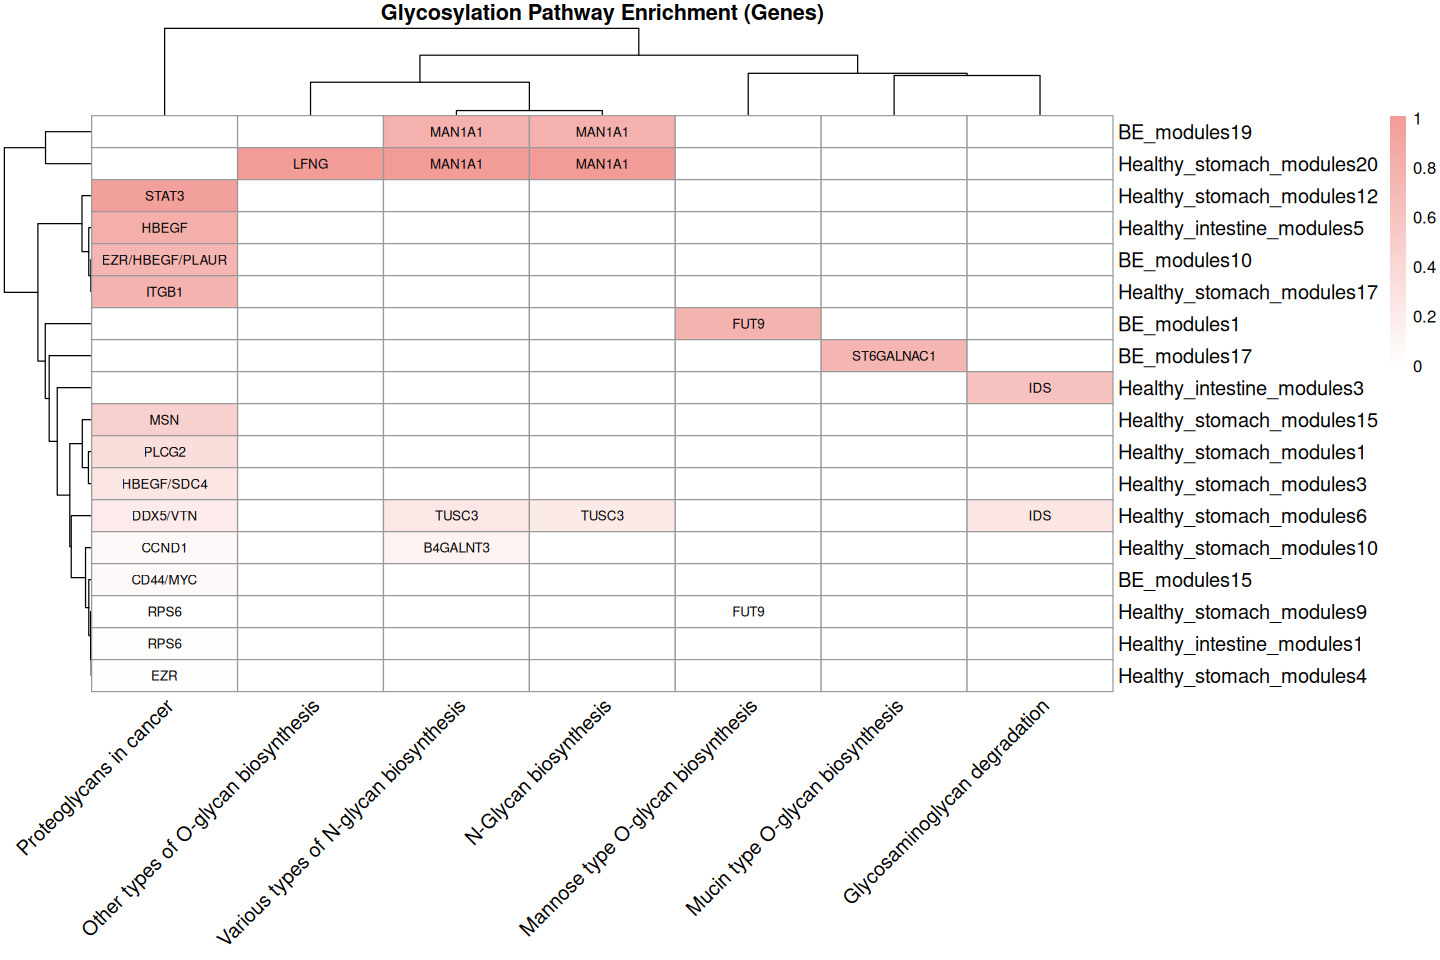

In [166]:
pheatmap(count_mat,
         angle_col = 45,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         color = colorRampPalette(c("white", "#f29c98"))(100),
         display_numbers = geneid_mat, 
         number_color = "black",
         fontsize_row = 12,
         fontsize_col = 12,
         fontsize_number = 8,
         main = "Glycosylation Pathway Enrichment (Genes)")

pdf 
  3

pdf 
  3

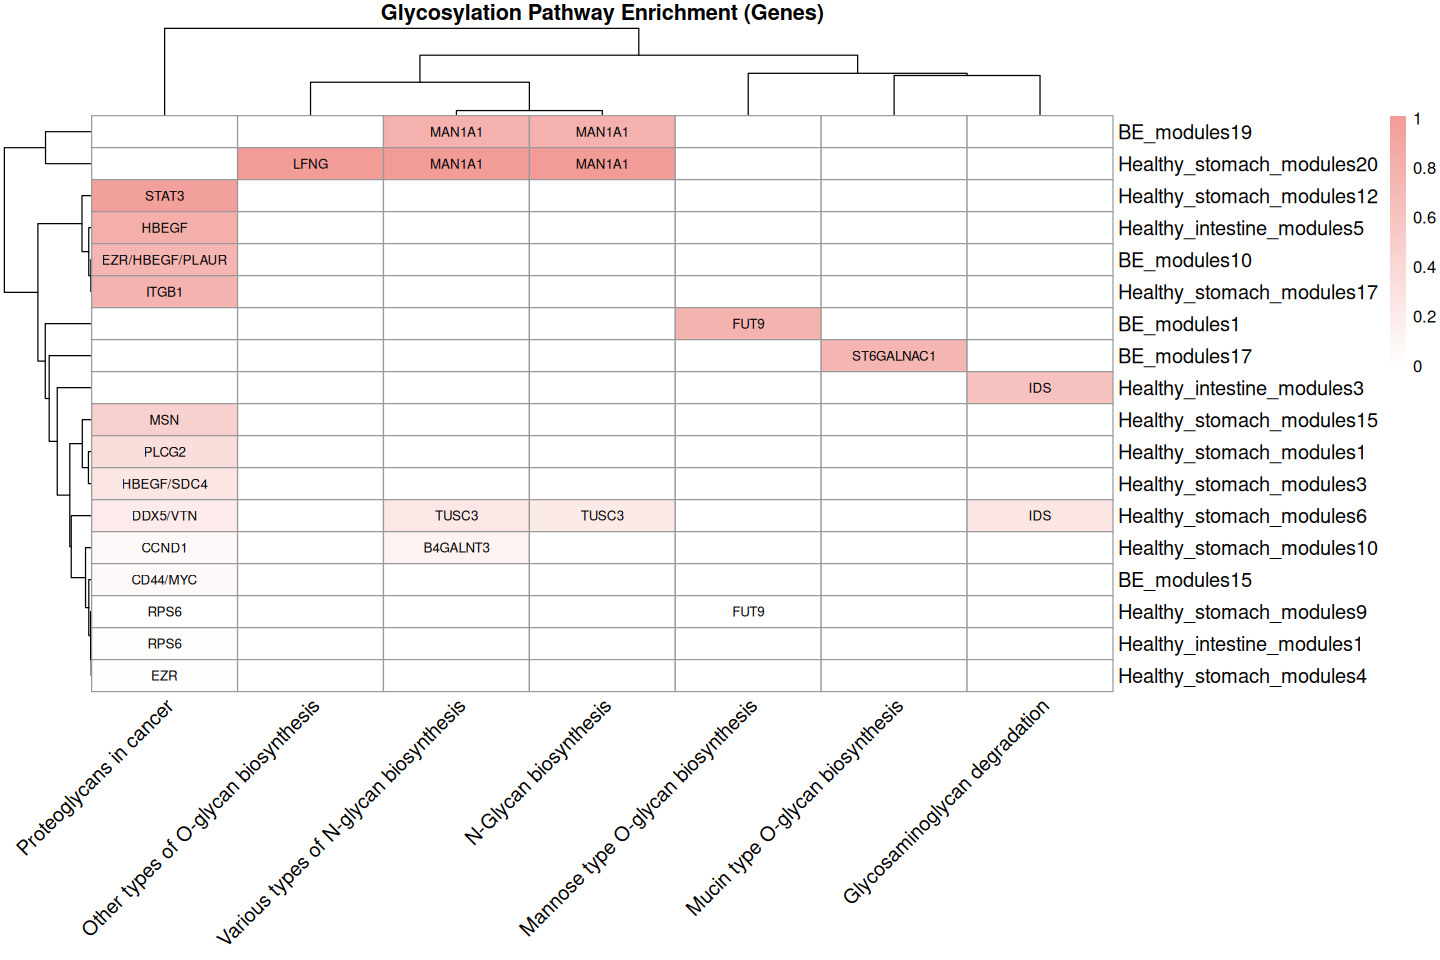

In [170]:
set.seed(123)

pdf('./06_pathwaybarplot.pdf',width = 12,height = 7)
pheatmap(count_mat,
         angle_col = 45,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         color = colorRampPalette(c("white", "#f29c98"))(100),
         display_numbers = geneid_mat, 
         number_color = "black",
         fontsize_row = 12,
         fontsize_col = 12,
         fontsize_number = 8,
         main = "Glycosylation Pathway Enrichment (Genes)")
dev.off() 
  

png('./06_pathwaybarplot.png',width = 12,height = 7,res = 600,units = 'in')
pheatmap(count_mat,
         angle_col = 45,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         color = colorRampPalette(c("white", "#f29c98"))(100),
         display_numbers = geneid_mat, 
         number_color = "black",
         fontsize_row = 12,
         fontsize_col = 12,
         fontsize_number = 8,
         main = "Glycosylation Pathway Enrichment (Genes)")
dev.off() 